Install Dependencies

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Performs automated cropping of all images in the YOLOv8 train/valid/test splits and updates the corresponding segmentation labels so that polygon coordinates remain correct after cropping, then writes the processed images, adjusted labels, and a copied data.yaml into a new dataset directory for downstream training.

In [ ]:
import os
import cv2
import shutil
from pathlib import Path

DATASET_PATH = "/content/drive/MyDrive/Jhpiego_data.v1-trial_1.yolov8"
OUTPUT_PATH = "/content/drive/MyDrive/jhpiego_cropped"  # Output path for cropped dataset

# Crop settings (in pixels)
CROP_TOP = 275
CROP_BOTTOM = 1100
CROP_LEFT = 250
CROP_RIGHT = 250

def crop_image(image_path, output_path):
    """Crop image and return new dimensions"""
    img = cv2.imread(image_path)
    if img is None:
        print(f"Warning: Could not read {image_path}")
        return None, None

    h, w = img.shape[:2]

    y_start = CROP_TOP
    y_end = h - CROP_BOTTOM
    x_start = CROP_LEFT
    x_end = w - CROP_RIGHT

    cropped_img = img[y_start:y_end, x_start:x_end]
    cv2.imwrite(output_path, cropped_img)

    return w, h, cropped_img.shape[1], cropped_img.shape[0]

def adjust_yolo_coordinates(label_path, output_path, original_w, original_h, new_w, new_h):
    """Adjust YOLO segmentation coordinates after cropping"""

    with open(label_path, 'r') as f:
        lines = f.readlines()

    adjusted_lines = []

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3:
            continue

        class_id = parts[0]
        coords = [float(x) for x in parts[1:]]

        adjusted_coords = []
        valid_polygon = True

        for i in range(0, len(coords), 2):
            x_abs = coords[i] * original_w
            y_abs = coords[i + 1] * original_h

            x_abs_cropped = x_abs - CROP_LEFT
            y_abs_cropped = y_abs - CROP_TOP


            if x_abs_cropped < 0 or x_abs_cropped > new_w or y_abs_cropped < 0 or y_abs_cropped > new_h:

                x_abs_cropped = max(0, min(x_abs_cropped, new_w))
                y_abs_cropped = max(0, min(y_abs_cropped, new_h))


            x_norm = x_abs_cropped / new_w
            y_norm = y_abs_cropped / new_h

            adjusted_coords.extend([x_norm, y_norm])

        if valid_polygon and len(adjusted_coords) >= 6:
            adjusted_line = f"{class_id} " + " ".join([f"{coord:.6f}" for coord in adjusted_coords])
            adjusted_lines.append(adjusted_line)

    with open(output_path, 'w') as f:
        for line in adjusted_lines:
            f.write(line + '\n')

    return len(adjusted_lines) > 0

def process_split(split_name):
    """Process train/valid/test split"""
    print(f"\nProcessing {split_name} split...")

    input_imgs = Path(DATASET_PATH) / split_name / "images"
    input_labels = Path(DATASET_PATH) / split_name / "labels"

    output_imgs = Path(OUTPUT_PATH) / split_name / "images"
    output_labels = Path(OUTPUT_PATH) / split_name / "labels"


    output_imgs.mkdir(parents=True, exist_ok=True)
    output_labels.mkdir(parents=True, exist_ok=True)


    image_files = list(input_imgs.glob("*.jpg")) + list(input_imgs.glob("*.png")) + list(input_imgs.glob("*.jpeg"))

    processed = 0
    skipped = 0

    for img_path in image_files:

        output_img_path = output_imgs / img_path.name
        original_w, original_h, new_w, new_h = crop_image(str(img_path), str(output_img_path))

        if original_w is None:
            skipped += 1
            continue


        label_path = input_labels / (img_path.stem + ".txt")
        output_label_path = output_labels / (img_path.stem + ".txt")

        if label_path.exists():
            has_annotations = adjust_yolo_coordinates(
                str(label_path),
                str(output_label_path),
                original_w, original_h, new_w, new_h
            )

            if not has_annotations:
                print(f"Warning: {img_path.name} has no annotations after cropping")
        else:
            output_label_path.touch()

        processed += 1
        if processed % 10 == 0:
            print(f"  Processed {processed}/{len(image_files)} images...")

    print(f"  ✓ Completed: {processed} images processed, {skipped} skipped")

def copy_data_yaml():
    """Copy and update data.yaml file"""
    input_yaml = Path(DATASET_PATH) / "data.yaml"
    output_yaml = Path(OUTPUT_PATH) / "data.yaml"

    if input_yaml.exists():
        shutil.copy(input_yaml, output_yaml)
        print(f"\n✓ Copied data.yaml to {OUTPUT_PATH}")
    else:
        print("\nWarning: data.yaml not found")

def main():
    print("=" * 60)
    print("YOLOv8 Segmentation Dataset Cropper")
    print("=" * 60)
    print(f"Input dataset: {DATASET_PATH}")
    print(f"Output dataset: {OUTPUT_PATH}")
    print(f"Crop settings: Top={CROP_TOP}px, Bottom={CROP_BOTTOM}px, Left={CROP_LEFT}px, Right={CROP_RIGHT}px")

    # Process each split
    for split in ['train', 'valid', 'test']:
        split_path = Path(DATASET_PATH) / split
        if split_path.exists():
            process_split(split)
        else:
            print(f"\n{split} split not found, skipping...")

    # Copy data.yaml
    copy_data_yaml()

    print("\n" + "=" * 60)
    print("✓ Processing complete!")
    print(f"Cropped dataset saved to: {OUTPUT_PATH}")
    print("=" * 60)

if __name__ == "__main__":
    main()

YOLOv8 Segmentation Dataset Cropper
Input dataset: /content/drive/MyDrive/Jhpiego_data.v1-trial_1.yolov8
Output dataset: /content/drive/MyDrive/jhpiego_cropped
Crop settings: Top=275px, Bottom=1100px, Left=250px, Right=250px

Processing train split...
  Processed 10/121 images...
  Processed 20/121 images...
  Processed 30/121 images...
  Processed 40/121 images...
  Processed 50/121 images...
  Processed 60/121 images...
  Processed 70/121 images...
  Processed 80/121 images...
  Processed 90/121 images...
  Processed 100/121 images...
  Processed 110/121 images...
  Processed 120/121 images...
  ✓ Completed: 121 images processed, 0 skipped

Processing valid split...
  Processed 10/18 images...
  ✓ Completed: 18 images processed, 0 skipped

Processing test split...
  Processed 10/17 images...
  ✓ Completed: 17 images processed, 0 skipped

✓ Copied data.yaml to /content/drive/MyDrive/jhpiego_cropped

✓ Processing complete!
Cropped dataset saved to: /content/drive/MyDrive/jhpiego_croppe

Trains a YOLOv8 Nano segmentation model (yolov8n‑seg) on the cropped Jhpiego dataset for 100 epochs at 640×640 resolution with batch size 16, using a cosine LR schedule and automatic optimizer selection, then runs validation, generates detailed training metric plots (losses, mAP, precision/recall), and saves sample test predictions and the best model weights for later inference.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting YOLOv8n Segmentation Training
Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/jhpiego_cropped/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s

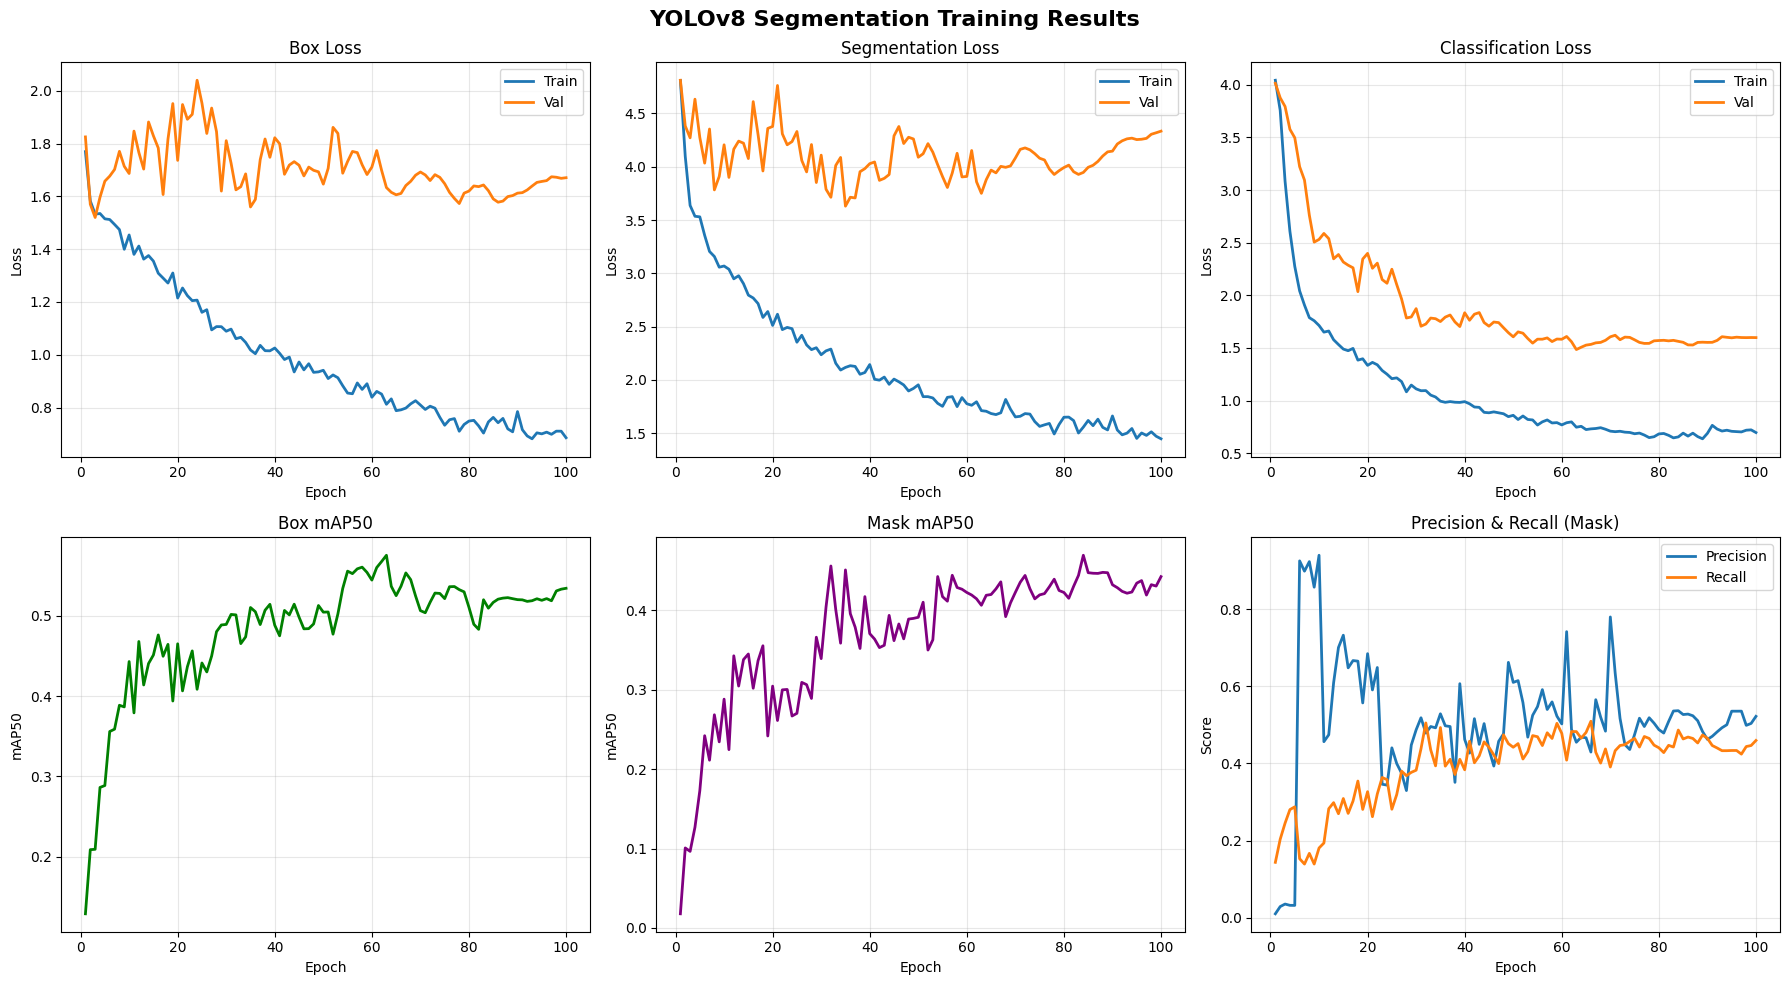


Testing Model on Sample Images

image 1/1 /content/drive/MyDrive/jhpiego_cropped/test/images/via_img_001_jpg.rf.9f324a34124a00c0e60afe29ca1ddc87.jpg: 448x640 1 Cervix, 1 Lesion, 2 noises, 80.3ms
Speed: 3.5ms preprocess, 80.3ms inference, 9.7ms postprocess per image at shape (1, 3, 448, 640)
  ✓ Saved prediction: via_img_001_jpg.rf.9f324a34124a00c0e60afe29ca1ddc87.jpg

image 1/1 /content/drive/MyDrive/jhpiego_cropped/test/images/via_img_038_jpg.rf.d52d6456bbb743ffb0700358d423ec5b.jpg: 448x640 1 Cervix, 1 Lesion, 1 SCJ, 2 noises, 11.7ms
Speed: 3.0ms preprocess, 11.7ms inference, 2.9ms postprocess per image at shape (1, 3, 448, 640)
  ✓ Saved prediction: via_img_038_jpg.rf.d52d6456bbb743ffb0700358d423ec5b.jpg

image 1/1 /content/drive/MyDrive/jhpiego_cropped/test/images/via_img_050_jpg.rf.5e042f2caf6be4498e012b8179d637f9.jpg: 448x640 1 Cervix, 1 SCJ, 1 noise, 14.2ms
Speed: 2.9ms preprocess, 14.2ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)
  ✓ Saved prediction: via_

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import cv2
import numpy as np

DATA_YAML = "/content/drive/MyDrive/jhpiego_cropped/data.yaml"
MODEL_NAME = "yolov8n-seg.pt"  # Nano model for segmentation
EPOCHS = 100
IMG_SIZE = 640
BATCH_SIZE = 16
PROJECT_NAME = "runs/segment"
EXPERIMENT_NAME = "jhpiego_seg"

def train_model():
    """Train YOLOv8 segmentation model"""
    print("=" * 60)
    print("Starting YOLOv8n Segmentation Training")
    print("=" * 60)

    model = YOLO(MODEL_NAME)

    # Train the model
    results = model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=PROJECT_NAME,
        name=EXPERIMENT_NAME,
        save=True,
        plots=True,
        device=0,
        verbose=True,
        workers=8,
        optimizer='auto',
        lr0=0.01,
        cos_lr=True,
    )

    print("\n✓ Training completed!")
    return model, results

def validate_model(model):
    """Validate the trained model"""
    print("\n" + "=" * 60)
    print("Running Validation")
    print("=" * 60)

    metrics = model.val()

    print("\n📊 Validation Metrics:")
    print(f"  • Box mAP50: {metrics.box.map50:.4f}")
    print(f"  • Box mAP50-95: {metrics.box.map:.4f}")
    print(f"  • Mask mAP50: {metrics.seg.map50:.4f}")
    print(f"  • Mask mAP50-95: {metrics.seg.map:.4f}")

    return metrics

def plot_training_results(results_dir):
    """Plot training metrics from results.csv"""
    print("\n" + "=" * 60)
    print("Generating Training Plots")
    print("=" * 60)

    results_csv = Path(results_dir) / "results.csv"

    if not results_csv.exists():
        print("⚠ results.csv not found!")
        return

    # Read results
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('YOLOv8 Segmentation Training Results', fontsize=16, fontweight='bold')

    # Plot 1: Box Loss
    ax = axes[0, 0]
    ax.plot(df['epoch'], df['train/box_loss'], label='Train', linewidth=2)
    ax.plot(df['epoch'], df['val/box_loss'], label='Val', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Box Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Segmentation Loss
    ax = axes[0, 1]
    ax.plot(df['epoch'], df['train/seg_loss'], label='Train', linewidth=2)
    ax.plot(df['epoch'], df['val/seg_loss'], label='Val', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Segmentation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: Class Loss
    ax = axes[0, 2]
    ax.plot(df['epoch'], df['train/cls_loss'], label='Train', linewidth=2)
    ax.plot(df['epoch'], df['val/cls_loss'], label='Val', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Classification Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 4: mAP50 (Box)
    ax = axes[1, 0]
    ax.plot(df['epoch'], df['metrics/mAP50(B)'], linewidth=2, color='green')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP50')
    ax.set_title('Box mAP50')
    ax.grid(True, alpha=0.3)

    # Plot 5: mAP50 (Mask)
    ax = axes[1, 1]
    ax.plot(df['epoch'], df['metrics/mAP50(M)'], linewidth=2, color='purple')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP50')
    ax.set_title('Mask mAP50')
    ax.grid(True, alpha=0.3)

    # Plot 6: Precision & Recall (Mask)
    ax = axes[1, 2]
    ax.plot(df['epoch'], df['metrics/precision(M)'], label='Precision', linewidth=2)
    ax.plot(df['epoch'], df['metrics/recall(M)'], label='Recall', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall (Mask)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save plot
    plot_path = Path(results_dir) / "training_plots.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"✓ Plots saved to: {plot_path}")
    plt.show()

def test_predictions(model, results_dir, num_images=5):
    """Run predictions on test images and visualize"""
    print("\n" + "=" * 60)
    print("Testing Model on Sample Images")
    print("=" * 60)

    test_img_dir = Path("/content/drive/MyDrive/jhpiego_cropped/test/images")

    if not test_img_dir.exists():
        print("⚠ Test images directory not found!")
        return

    test_images = list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png"))
    test_images = test_images[:num_images]

    if not test_images:
        print("⚠ No test images found!")
        return

    output_dir = Path(results_dir) / "test_predictions"
    output_dir.mkdir(exist_ok=True)

    for img_path in test_images:
        results = model.predict(source=str(img_path), conf=0.25, save=False)

        annotated = results[0].plot()

        output_path = output_dir / img_path.name
        cv2.imwrite(str(output_path), annotated)
        print(f"  ✓ Saved prediction: {output_path.name}")

    print(f"\n✓ Test predictions saved to: {output_dir}")

def main():
    """Main training pipeline"""

    # 1. Train the model
    model, results = train_model()

    # Get results directory
    results_dir = Path(PROJECT_NAME) / EXPERIMENT_NAME

    # 2. Validate
    metrics = validate_model(model)

    # 3. Plot training results
    plot_training_results(results_dir)

    # 4. Test predictions
    test_predictions(model, results_dir)

    # 5. Print final summary
    print("\n" + "=" * 60)
    print("TRAINING SUMMARY")
    print("=" * 60)
    print(f"✓ Model saved at: {results_dir / 'weights/best.pt'}")
    print(f"✓ Results directory: {results_dir}")
    print(f"✓ Best Mask mAP50: {metrics.seg.map50:.4f}")
    print(f"✓ Best Mask mAP50-95: {metrics.seg.map:.4f}")
    print("\nTo use the trained model:")
    print(f"  from ultralytics import YOLO")
    print(f"  model = YOLO('{results_dir}/weights/best.pt')")
    print(f"  results = model.predict('image.jpg')")
    print("=" * 60)

if __name__ == "__main__":
    if not Path(DATA_YAML).exists():
        print(f"❌ Error: {DATA_YAML} not found!")
        print("Please make sure you've run the cropping script first.")
    else:
        main()

The overall scores (Box mAP50 ≈ 0.53, Mask mAP50 ≈ 0.44) indicate moderate detection and segmentation quality, with performance varying strongly by class: Cervix is learned very well (near-perfect precision/recall and high mAP), SCJ and noise are reasonably good, while Lesion performance is poor due to low precision and very low recall, meaning many lesions are missed and some predictions are incorrect.



---

Train a segmentation model on JHPIEGO dataset using both standard YOLOv8s-seg and a custom hybrid YOLOv8-ResNet50 architecture for improved feature extraction and accuracy.

Training Stages:
1. Baseline Training: 200 epochs with augmentation + AdamW optimizer.
2. Hybrid Training (3-stage fine-tuning):
   - Stage 1: Train head (freeze backbone, 30 epochs).  
   - Stage 2: Fine-tune full model (100 epochs, low LR).  
   - Stage 3: Extended fine-tuning (70 epochs, heavy augmentation).  

In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.nn.modules import Conv, C2f, SPPF, Concat, Detect, Segment
from ultralytics.nn.tasks import DetectionModel
import torchvision.models as models
from pathlib import Path
import json

class ResNet50Backbone(nn.Module):
    """
    ResNet-50 backbone that outputs multi-scale features
    Compatible with YOLOv8 FPN architecture
    """
    def __init__(self, pretrained_path=None):
        super().__init__()
        resnet = models.resnet50(pretrained=False)

        if pretrained_path:
            print(f"Loading pretrained weights from {pretrained_path}")
            state_dict = torch.load(pretrained_path, map_location='cpu', weights_only=False)

            if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
                state_dict = state_dict['model_state_dict']
            elif isinstance(state_dict, dict) and 'state_dict' in state_dict:
                state_dict = state_dict['state_dict']

            state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
            resnet.load_state_dict(state_dict, strict=False)
            print("✓ Loaded pretrained ResNet-50 weights")

        self.stem = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool
        )

        # ResNet stages
        self.stage1 = resnet.layer1  # Output: 256 channels
        self.stage2 = resnet.layer2  # Output: 512 channels
        self.stage3 = resnet.layer3  # Output: 1024 channels
        self.stage4 = resnet.layer4  # Output: 2048 channels

        # Channel reduction layers to match YOLOv8 dimensions
        self.reduce2 = Conv(512, 128, 1, 1)    # P3: 128 channels
        self.reduce3 = Conv(1024, 256, 1, 1)   # P4: 256 channels
        self.reduce4 = Conv(2048, 512, 1, 1)   # P5: 512 channels

    def forward(self, x):
        """
        Forward pass returning multi-scale features
        Returns: [P3, P4, P5] for FPN
        """
        # Stem
        x = self.stem(x)

        # ResNet stages
        c2 = self.stage1(x)   # 1/4 resolution
        c3 = self.stage2(c2)  # 1/8 resolution
        c4 = self.stage3(c3)  # 1/16 resolution
        c5 = self.stage4(c4)  # 1/32 resolution

        # Reduce channels
        p3 = self.reduce2(c3)  # 128 channels
        p4 = self.reduce3(c4)  # 256 channels
        p5 = self.reduce4(c5)  # 512 channels

        return p3, p4, p5

class YOLOv8_ResNet50(nn.Module):
    """
    YOLOv8 segmentation model with ResNet-50 backbone
    """
    def __init__(self, nc=7, pretrained_path=None):
        super().__init__()

        self.nc = nc  # Number of classes

        # Backbone: ResNet-50
        self.backbone = ResNet50Backbone(pretrained_path)

        # Neck: Feature Pyramid Network (same as YOLOv8)
        # P5 processing
        self.sppf = SPPF(512, 512, k=5)

        # Upsample and concatenate
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.c2f1 = C2f(512 + 256, 256, n=1, shortcut=False)  # P4 fusion

        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.c2f2 = C2f(256 + 128, 128, n=1, shortcut=False)  # P3 fusion

        # Downsample path
        self.conv1 = Conv(128, 128, 3, 2)
        self.c2f3 = C2f(128 + 256, 256, n=1, shortcut=False)  # P4

        self.conv2 = Conv(256, 256, 3, 2)
        self.c2f4 = C2f(256 + 512, 512, n=1, shortcut=False)  # P5

        # Head: Segmentation + Detection
        self.head = Segment(nc, nm=32, nc_list=[128, 256, 512])

    def forward(self, x):
        """Forward pass"""
        # Backbone
        p3, p4, p5 = self.backbone(x)

        # Neck - Top-down pathway
        p5 = self.sppf(p5)

        p5_up = self.up1(p5)
        p4_fused = torch.cat([p5_up, p4], dim=1)
        p4_out = self.c2f1(p4_fused)

        p4_up = self.up2(p4_out)
        p3_fused = torch.cat([p4_up, p3], dim=1)
        p3_out = self.c2f2(p3_fused)

        # Bottom-up pathway
        p3_down = self.conv1(p3_out)
        p4_fused2 = torch.cat([p3_down, p4_out], dim=1)
        p4_out2 = self.c2f3(p4_fused2)

        p4_down = self.conv2(p4_out2)
        p5_fused = torch.cat([p4_down, p5], dim=1)
        p5_out = self.c2f4(p5_fused)

        # Head
        outputs = self.head([p3_out, p4_out2, p5_out])

        return outputs

def train_baseline_model(
    data_yaml,
    epochs=200,
    batch_size=8,
    project_name="runs/segment",
    experiment_name="yolov8s_baseline"
):
    """
    Train baseline YOLOv8s-seg model
    """
    print("\n" + "=" * 80)
    print("🚀 TRAINING BASELINE YOLOv8s-seg MODEL")
    print("=" * 80)

    # Load pretrained YOLOv8s-seg
    model = YOLO("yolov8s-seg.pt")

    print(f"Model: YOLOv8s-seg (standard backbone)")
    print(f"Training for {epochs} epochs")
    print(f"Batch size: {batch_size}")

    # Train
    results = model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=640,
        batch=batch_size,
        project=project_name,
        name=experiment_name,

        # Optimizer settings
        optimizer='AdamW',
        lr0=0.001,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,

        # Augmentation settings
        degrees=25.0,
        translate=0.2,
        scale=0.8,
        shear=5.0,
        perspective=0.001,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.2,
        copy_paste=0.3,

        # Color augmentation
        hsv_h=0.02,
        hsv_s=0.8,
        hsv_v=0.5,

        patience=50,
        save=True,
        plots=True,
        verbose=True,
    )

    # Validate
    print("\nValidating baseline model...")
    metrics = model.val(data=data_yaml)

    baseline_results = {
        'mask_map50': float(metrics.seg.map50),
        'mask_map': float(metrics.seg.map),
        'box_map50': float(metrics.box.map50),
        'box_map': float(metrics.box.map),
        'model_path': f"{project_name}/{experiment_name}/weights/best.pt"
    }

    print("\n✅ BASELINE TRAINING COMPLETE")
    print("=" * 80)
    print(f"Mask mAP50:     {baseline_results['mask_map50']:.4f}")
    print(f"Mask mAP50-95:  {baseline_results['mask_map']:.4f}")
    print(f"Box mAP50:      {baseline_results['box_map50']:.4f}")
    print(f"Box mAP50-95:   {baseline_results['box_map']:.4f}")
    print(f"Best model:     {baseline_results['model_path']}")
    print("=" * 80)

    # Save results
    baseline_file = f"{project_name}/{experiment_name}/baseline_results.json"
    with open(baseline_file, 'w') as f:
        json.dump(baseline_results, f, indent=4)
    print(f"Results saved to: {baseline_file}")

    return model, baseline_results

def hybrid_resnet_yolo_training(
    data_yaml,
    resnet_checkpoint,
    epochs=200,
    batch_size=8
):
    """
    3-Stage ResNet + YOLOv8 Hybrid Training
    """
    print("\n" + "=" * 80)
    print("🚀 HYBRID RESNET + YOLOv8 TRAINING")
    print("=" * 80)

    print("Loading ResNet-50 pretrained weights...")
    resnet = models.resnet50(pretrained=False)
    state_dict = torch.load(resnet_checkpoint, map_location='cpu', weights_only=False)

    if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
        state_dict = state_dict['model_state_dict']

    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    resnet.load_state_dict(state_dict, strict=False)
    print("✓ Loaded ResNet weights")

    model = YOLO("yolov8s-seg.pt")

    print("\nTransferring compatible layers...")
    yolo_dict = model.model.state_dict()
    transferred = 0

    # Transfer first conv layer (conv1)
    if 'conv1.weight' in state_dict:
        resnet_conv1 = state_dict['conv1.weight']  # [64, 3, 7, 7]

        # YOLOv8 first layer
        yolo_first_conv = 'model.0.conv.weight'
        if yolo_first_conv in yolo_dict:
            yolo_weight = yolo_dict[yolo_first_conv]  # [32, 3, 3, 3]

            # Adapt: Crop ResNet's 7x7 to 3x3 and reduce channels
            adapted_weight = resnet_conv1[:32, :, 2:5, 2:5]  # Center crop

            if adapted_weight.shape == yolo_weight.shape:
                yolo_dict[yolo_first_conv] = adapted_weight
                transferred += 1
                print(f"  ✓ Transferred: conv1 → model.0.conv")

    # Transfer batch norm from conv1
    bn_pairs = [
        ('bn1.weight', 'model.0.bn.weight'),
        ('bn1.bias', 'model.0.bn.bias'),
        ('bn1.running_mean', 'model.0.bn.running_mean'),
        ('bn1.running_var', 'model.0.bn.running_var'),
    ]

    for resnet_key, yolo_key in bn_pairs:
        if resnet_key in state_dict and yolo_key in yolo_dict:
            if state_dict[resnet_key].shape == yolo_dict[yolo_key].shape:
                yolo_dict[yolo_key] = state_dict[resnet_key]
                transferred += 1

    # Load modified weights
    model.model.load_state_dict(yolo_dict, strict=False)
    print(f"✓ Transferred {transferred} compatible layers")

    # STAGE 1: Freeze backbone, train head
    print("\n" + "=" * 80)
    print("STAGE 1: Training HEAD (backbone frozen) - 30 epochs")
    print("=" * 80)

    # Freeze backbone
    for name, param in model.model.named_parameters():
        if 'model.' in name:
            layer_idx = int(name.split('.')[1]) if name.split('.')[1].isdigit() else -1
            if 0 <= layer_idx <= 9:
                param.requires_grad = False

    stage1_results = model.train(
        data=data_yaml,
        epochs=30,
        imgsz=640,
        batch=batch_size,
        project="runs/segment",
        name="resnet_yolo_stage1",

        # High LR for head
        optimizer='AdamW',
        lr0=0.001,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,

        # Moderate augmentation
        degrees=15.0,
        translate=0.1,
        scale=0.5,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.1,

        patience=30,
        save=True,
        plots=True,
        verbose=True,
    )

    # STAGE 2: Unfreeze backbone, fine-tune
    print("\n" + "=" * 80)
    print("STAGE 2: Fine-tuning ENTIRE MODEL - 100 epochs")
    print("=" * 80)

    # Load the best weights from stage 1
    best_stage1 = "runs/segment/resnet_yolo_stage1/weights/last.pt"
    model = YOLO(best_stage1)  # Reload model with stage 1 weights

    stage2_results = model.train(
        data=data_yaml,
        epochs=100,
        imgsz=640,
        batch=batch_size,
        project="runs/segment",
        name="resnet_yolo_stage2",
        resume=False,

        # Very low LR for fine-tuning
        optimizer='AdamW',
        lr0=0.0001,  # Lower!
        lrf=0.00001,
        weight_decay=0.001,

        # HEAVY augmentation to prevent overfitting
        degrees=25.0,
        translate=0.2,
        scale=0.8,
        shear=5.0,
        perspective=0.001,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.2,
        copy_paste=0.3,

        # Stronger regularization
        dropout=0.1,

        # Color augmentation
        hsv_h=0.02,
        hsv_s=0.8,
        hsv_v=0.5,

        patience=50,
        save=True,
        plots=True,
        verbose=True,
    )

    # STAGE 3: Extended training
    print("\n" + "=" * 80)
    print("STAGE 3: Extended training - 70 epochs")
    print("=" * 80)

    # Load the best weights from stage 2
    best_stage2 = "runs/segment/resnet_yolo_stage2/weights/last.pt"
    model = YOLO(best_stage2)  # Reload model with stage 2 weights

    stage3_results = model.train(
        data=data_yaml,
        epochs=70,
        imgsz=640,
        batch=batch_size,
        project="runs/segment",
        name="resnet_yolo_stage3",
        resume=False,

        # Even lower LR
        lr0=0.00005,
        lrf=0.000001,

        # Maximum augmentation
        degrees=30.0,
        translate=0.2,
        scale=0.9,
        shear=10.0,
        mosaic=1.0,
        mixup=0.3,
        copy_paste=0.4,

        patience=70,
        verbose=True,
    )

    print("\n✅ RESNET HYBRID TRAINING COMPLETE")
    print("=" * 80)
    print("Best models saved:")
    print("  Stage1: runs/segment/resnet_yolo_stage1/weights/best.pt")
    print("  Stage2: runs/segment/resnet_yolo_stage2/weights/best.pt")
    print("  Stage3: runs/segment/resnet_yolo_stage3/weights/best.pt")
    print("=" * 80)

    return model, stage1_results, stage2_results, stage3_results

if __name__ == "__main__":
    DATA_YAML = "/content/drive/MyDrive/jhpiego_cropped/data.yaml"
    RESNET_CHECKPOINT = "/content/ssl_backbone_resnet50_epoch48 1.pth"

    print("🚀 Starting Complete Training Pipeline")
    print(f"Dataset: {DATA_YAML}")
    print(f"Pretrained backbone: {RESNET_CHECKPOINT}")
    print("=" * 80)

    # STEP 1: Train baseline model
    print("\n📋 STEP 1: Training Baseline YOLOv8s-seg")
    baseline_model, baseline_results = train_baseline_model(
        data_yaml=DATA_YAML,
        epochs=200,
        batch_size=8,
        experiment_name="yolov8s_baseline_new"
    )

    # STEP 2: Train ResNet hybrid model
    print("\n📋 STEP 2: Training ResNet + YOLOv8 Hybrid")
    model, stage1, stage2, stage3 = hybrid_resnet_yolo_training(
        data_yaml=DATA_YAML,
        resnet_checkpoint=RESNET_CHECKPOINT,
        epochs=200,
        batch_size=8
    )

    print("\n" + "=" * 80)
    print("✅ COMPLETE TRAINING PIPELINE FINISHED!")
    print("=" * 80)
    print("\n📁 All models saved in: runs/segment/")
    print("\n🎯 Next steps:")
    print("1. Check TensorBoard: tensorboard --logdir runs/segment")
    print("2. Test best models:")
    print("   model = YOLO('runs/segment/resnet_yolo_stage3/weights/best.pt')")
    print("   results = model.val()")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Starting Complete Training Pipeline
Dataset: /content/drive/MyDrive/jhpiego_cropped/data.yaml
Pretrained backbone: /content/ssl_backbone_resnet50_epoch48 1.pth

📋 STEP 1: Training Baseline YOLOv8s-seg

🚀 TRAINING BASELINE YOLOv8s-seg MODEL
Model: YOLOv8s-seg (standard backbone)
Training for 200 epochs
Batch size: 8
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Loaded ResNet weights

Transferring compatible layers...
  ✓ Transferred: conv1 → model.0.conv
✓ Transferred 1 compatible layers

STAGE 1: Training HEAD (backbone frozen) - 30 epochs
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/jhpiego_cropped/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, m

Baseline (YOLOv8s-seg):
The baseline YOLOv8s-seg model achieved solid detection and mask accuracy, with strong performance on *Cervix* and *SCJ* classes and stable segmentation quality. However, lesion segmentation was weak and recall relatively low, showing limited fine-grained learning on small or irregular regions.

Hybrid Stage 1 (Head Training):
After initializing with ResNet features and training only the YOLO head, overall performance slightly dropped - expected since the backbone was frozen. Cervix remained strong, but lesion accuracy stayed very low. This stage mainly stabilized new layer weights.

Hybrid Stage 2 (Full Fine-tuning):
Once the full model was unfrozen and fine-tuned, both box and mask mAP recovered close to or slightly better than baseline. Improvements were seen in lesion and SCJ stability, indicating better feature transfer from the ResNet backbone.

Hybrid Stage 3 (Extended Training):
Extended training slightly refined generalization, with smoother performance across classes but marginal gains overall. The model maintained stable segmentation behavior, particularly for cervix and SCJ, while lesion detection remained the main weak spot.



---

Train a YOLOv8s-seg + ResNet-50 hybrid segmentation model on a combined 300-image cervical dataset: 120 images from the Jhpiego dataset and 180 additional images downloaded from the IARC Dataset and merged into a single YOLOv8-format dataset.

In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO
from pathlib import Path
import numpy as np
import yaml
import shutil
from datetime import datetime


class Config:

    DATASET_120_PATH = "/content/drive/MyDrive/jhpiego_cropped/data.yaml"
    COMBINED_DATASET_PATH = "/content/combined_300_dataset/data.yaml"

    RESNET_CHECKPOINT = "/content/ssl_backbone_resnet50_epoch48 1.pth"

    ROBOFLOW_API_KEY = "VUoMbrop9Wdsx5ONTwFv"
    ROBOFLOW_WORKSPACE = "cervicalcancergrp10"
    ROBOFLOW_PROJECT = "via_iarc-kgsvx"
    ROBOFLOW_VERSION = 2
    DOWNLOAD_DIR = "/content/jhpiego_180_images"

    # *** CHANGE HERE: use YOLOv8s-seg ***
    MODEL_SIZE = "yolov8s-seg.pt"
    IMG_SIZE = 640
    BATCH_SIZE = 6

    STAGE1_EPOCHS = 40   # Frozen backbone
    STAGE2_EPOCHS = 120  # Full fine-tuning
    STAGE3_EPOCHS = 80   # Extended training

    PROJECT_NAME = "runs/segment"


# --------- STEP 1: download_180_images (unchanged) ---------
def download_180_images(config=Config):
    print("STEP 1: DOWNLOADING 180 ADDITIONAL IMAGES FROM ROBOFLOW")

    try:
        from roboflow import Roboflow
    except ImportError:
        print("Installing roboflow...")
        import subprocess
        subprocess.check_call(['pip', 'install', '-q', 'roboflow'])
        from roboflow import Roboflow

    print(f"API Key: {config.ROBOFLOW_API_KEY[:10]}...")
    print(f"Workspace: {config.ROBOFLOW_WORKSPACE}")
    print(f"Project: {config.ROBOFLOW_PROJECT}")
    print(f"Version: {config.ROBOFLOW_VERSION}")
    print(f"Download to: {config.DOWNLOAD_DIR}")

    rf = Roboflow(api_key=config.ROBOFLOW_API_KEY)
    project = rf.workspace(config.ROBOFLOW_WORKSPACE).project(config.ROBOFLOW_PROJECT)
    dataset = project.version(config.ROBOFLOW_VERSION).download("yolov8", location=config.DOWNLOAD_DIR)

    print(f"\n✓ Dataset downloaded to: {config.DOWNLOAD_DIR}")

    data_yaml_path = Path(config.DOWNLOAD_DIR) / "data.yaml"

    if not data_yaml_path.exists():
        print("⚠️ Warning: data.yaml not found, creating it...")

        data_yaml_content = {
            'path': str(config.DOWNLOAD_DIR),
            'train': 'train/images',
            'val': 'valid/images',
            'test': 'test/images',
            'names': {0: 'Cervix', 1: 'Lesion', 2: 'SCJ', 3: 'noise'},
            'nc': 4
        }

        with open(data_yaml_path, 'w') as f:
            yaml.dump(data_yaml_content, f, default_flow_style=False)

    with open(data_yaml_path) as f:
        data_config = yaml.safe_load(f)

    train_path = Path(config.DOWNLOAD_DIR) / data_config.get('train', 'train/images')
    val_path = Path(config.DOWNLOAD_DIR) / data_config.get('val', 'valid/images')

    train_count = len(list(train_path.glob('*.*'))) if train_path.exists() else 0
    val_count = len(list(val_path.glob('*.*'))) if val_path.exists() else 0

    print(f"\n📊 180-Image Dataset Statistics:")
    print(f"  Training images:   {train_count}")
    print(f"  Validation images: {val_count}")
    print(f"  Total images:      {train_count + val_count}")
    print(f"  data.yaml:         {data_yaml_path}")

    return str(data_yaml_path)


# --------- STEP 2: combine_datasets (unchanged) ---------
def combine_datasets(dataset1_yaml, dataset2_yaml, output_dir="/content/combined_300_dataset"):
    print("\n" + "="*80)
    print("STEP 2: COMBINING DATASETS (120 + 180 = 300 images)")
    print("="*80)

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    for split in ['train', 'valid', 'test']:
        (output_path / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_path / split / 'labels').mkdir(parents=True, exist_ok=True)

    with open(dataset1_yaml) as f:
        config1 = yaml.safe_load(f)
    with open(dataset2_yaml) as f:
        config2 = yaml.safe_load(f)

    copied_count = {'train': 0, 'valid': 0, 'test': 0}

    def copy_dataset_split(config, base_path, split, prefix, output_path, copied_count):

        if 'path' in config:
            dataset_base = Path(config['path'])
        else:
            dataset_base = base_path

        split_key = split
        if split == 'valid' and 'valid' not in config and 'val' in config:
            split_key = 'val'
        elif split not in config:
            return

        split_path = config.get(split_key, f'{split}/images')

        if Path(split_path).is_absolute():
            images_path = Path(split_path)
        else:
            if split_path.startswith('../'):
                clean_path = split_path.replace('../', '')
                images_path = dataset_base / clean_path
            else:
                images_path = dataset_base / split_path

        if 'labels' in str(images_path):
            labels_path = images_path
        else:
            labels_path = images_path.parent / 'labels'
            if not labels_path.exists():
                labels_path = images_path.parent.parent / 'labels' / images_path.name.replace('images', '')
            if not labels_path.exists():
                labels_path = Path(str(images_path).replace('/images', '/labels'))

        print(f"  Looking for {split} in: {images_path}")

        if not images_path.exists():
            print(f"  ⚠️ No images found for {split}")
            return

        img_files = (list(images_path.glob('*.jpg')) +
                     list(images_path.glob('*.png')) +
                     list(images_path.glob('*.jpeg')) +
                     list(images_path.glob('*.JPG')))

        print(f"  Found {len(img_files)} images")

        for img_file in img_files:
            dst_img = output_path / split / 'images' / f"{prefix}_{img_file.name}"
            shutil.copy2(img_file, dst_img)
            copied_count[split] += 1

            label_file = labels_path / f"{img_file.stem}.txt"
            if label_file.exists():
                dst_label = output_path / split / 'labels' / f"{prefix}_{img_file.stem}.txt"
                shutil.copy2(label_file, dst_label)

    for split in ['train', 'valid', 'test']:
        print(f"\n📂 Processing {split} split:")
        print(f"  Dataset 1 (120 images):")
        base1 = Path(dataset1_yaml).parent
        copy_dataset_split(config1, base1, split, 'd1', output_path, copied_count)

        print(f"  Dataset 2 (180 images):")
        base2 = Path(dataset2_yaml).parent
        copy_dataset_split(config2, base2, split, 'd2', output_path, copied_count)

    combined_yaml = {
        'path': str(output_path),
        'train': 'train/images',
        'val': 'valid/images',
        'names': config1.get('names', {0: 'Cervix', 1: 'Lesion', 2: 'SCJ', 3: 'noise'}),
        'nc': config1.get('nc', 4)
    }

    if copied_count['test'] > 0:
        combined_yaml['test'] = 'test/images'

    combined_yaml_path = output_path / 'data.yaml'
    with open(combined_yaml_path, 'w') as f:
        yaml.dump(combined_yaml, f, default_flow_style=False)

    print(f"\n✓ Combined dataset created!")
    print(f"  Training:   {copied_count['train']} images")
    print(f"  Validation: {copied_count['valid']} images")
    print(f"  Test:       {copied_count['test']} images")
    print(f"  Total:      {sum(copied_count.values())} images")
    print(f"  data.yaml:  {combined_yaml_path}")

    train_check = len(list((output_path / 'train' / 'images').glob('*.*')))
    valid_check = len(list((output_path / 'valid' / 'images').glob('*.*')))

    if train_check == 0:
        raise ValueError("Failed to copy training images!")

    print(f"\n✓ Verification: {train_check} train, {valid_check} valid images")

    return str(combined_yaml_path)


# --------- STEP 3: transfer_resnet_weights (works with s or m) ---------
def transfer_resnet_weights(model, resnet_checkpoint):
    print("\n" + "="*80)
    print("STEP 3: TRANSFERRING RESNET-50 WEIGHTS TO YOLOv8s")
    print("="*80)

    print(f"\n📦 Loading: {resnet_checkpoint}")
    resnet_state = torch.load(resnet_checkpoint, map_location='cpu', weights_only=False)

    if isinstance(resnet_state, dict) and 'model_state_dict' in resnet_state:
        resnet_state = resnet_state['model_state_dict']
    elif isinstance(resnet_state, dict) and 'state_dict' in resnet_state:
        resnet_state = resnet_state['state_dict']

    resnet_state = {k.replace('module.', ''): v for k, v in resnet_state.items()}

    print(f"✓ Loaded {len(resnet_state)} ResNet parameters")

    yolo_state = model.model.state_dict()
    print(f"✓ YOLOv8s has {len(yolo_state)} parameters")

    print("\n🔄 Transferring weights...")
    transferred = 0

    for resnet_key, resnet_weight in resnet_state.items():
        if 'fc' in resnet_key or 'avgpool' in resnet_key:
            continue

        for yolo_key in yolo_state.keys():
            if not yolo_key.startswith('model.'):
                continue

            try:
                layer_num = int(yolo_key.split('.')[1])
            except:
                continue

            if layer_num >= 10:
                continue

            if yolo_state[yolo_key].shape == resnet_weight.shape:
                if (('conv' in resnet_key and 'conv' in yolo_key) or
                    ('bn' in resnet_key and 'bn' in yolo_key) or
                    ('weight' in resnet_key and 'weight' in yolo_key)):

                    yolo_state[yolo_key] = resnet_weight.clone()
                    transferred += 1
                    if transferred <= 10:
                        print(f"  ✓ {resnet_key[:35]:35s} → {yolo_key[:35]:35s}")
                    break

    model.model.load_state_dict(yolo_state, strict=False)

    print(f"\n✓ Transferred {transferred} layers from ResNet to YOLOv8s")
    print("="*80)

    return model


def freeze_backbone(model, freeze_until=9):
    print(f"\n❄️  Freezing backbone (layers 0-{freeze_until})")
    for name, param in model.model.named_parameters():
        if 'model.' in name:
            try:
                layer_idx = int(name.split('.')[1])
                if 0 <= layer_idx <= freeze_until:
                    param.requires_grad = False
            except:
                pass

    trainable = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    print(f"✓ Trainable parameters: {trainable:,}")
    return model


def unfreeze_all(model_path):
    print("\n🔓 Unfreezing all layers")
    model = YOLO(model_path)
    for param in model.model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    print(f"✓ All {trainable:,} parameters trainable")
    return model


def stage1_train_head(model, data_yaml, config=Config):
    print("\n" + "="*80)
    print("STAGE 1: TRAINING HEAD (Backbone Frozen)")
    print("="*80)
    print(f"Epochs: {config.STAGE1_EPOCHS}")

    results = model.train(
        data=data_yaml,
        epochs=config.STAGE1_EPOCHS,
        imgsz=config.IMG_SIZE,
        batch=config.BATCH_SIZE,
        project=config.PROJECT_NAME,
        name="resnet_s_stage1_frozen",
        optimizer='AdamW',
        lr0=0.001,
        lrf=0.01,
        warmup_epochs=3,
        degrees=15.0,
        translate=0.1,
        scale=0.5,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.1,
        copy_paste=0.2,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        patience=40,
        save=True,
        verbose=True,
    )
    print("\n✅ Stage 1 Complete!")
    return results


def stage2_finetune_all(model, data_yaml, config=Config):
    print("\n" + "="*80)
    print("STAGE 2: FINE-TUNING ENTIRE MODEL")
    print("="*80)
    print(f"Epochs: {config.STAGE2_EPOCHS}")

    results = model.train(
        data=data_yaml,
        epochs=config.STAGE2_EPOCHS,
        imgsz=config.IMG_SIZE,
        batch=config.BATCH_SIZE,
        project=config.PROJECT_NAME,
        name="resnet_s_stage2_full",
        resume=False,
        optimizer='AdamW',
        lr0=0.0001,
        lrf=0.00001,
        warmup_epochs=5,
        degrees=30.0,
        translate=0.2,
        scale=0.8,
        shear=10.0,
        perspective=0.0005,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.3,
        copy_paste=0.5,
        hsv_h=0.05,
        hsv_s=0.9,
        hsv_v=0.6,
        dropout=0.1,
        patience=50,
        save=True,
        save_period=10,
        verbose=True,
    )
    print("\n✅ Stage 2 Complete!")
    return results


def stage3_extended(model, data_yaml, config=Config):
    print("\n" + "="*80)
    print("STAGE 3: EXTENDED TRAINING")
    print("="*80)
    print(f"Epochs: {config.STAGE3_EPOCHS}")

    results = model.train(
        data=data_yaml,
        epochs=config.STAGE3_EPOCHS,
        imgsz=config.IMG_SIZE,
        batch=config.BATCH_SIZE,
        project=config.PROJECT_NAME,
        name="resnet_s_stage3_extended",
        resume=False,
        optimizer='AdamW',
        lr0=0.00005,
        lrf=0.000005,
        warmup_epochs=3,
        degrees=35.0,
        translate=0.3,
        scale=0.9,
        shear=15.0,
        perspective=0.0005,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.4,
        copy_paste=0.6,
        hsv_h=0.08,
        hsv_s=1.0,
        hsv_v=0.7,
        dropout=0.15,
        patience=60,
        save=True,
        verbose=True,
    )
    print("\n✅ Stage 3 Complete!")
    return results


def validate_stage(model, data_yaml, stage_name):
    print(f"\n📊 Validating {stage_name}...")
    metrics = model.val(data=data_yaml)

    with open(data_yaml) as f:
        config = yaml.safe_load(f)

    class_names = config.get('names', [])
    if isinstance(class_names, dict):
        max_idx = max(class_names.keys()) if class_names else 0
        names_list = [''] * (max_idx + 1)
        for idx, name in class_names.items():
            names_list[idx] = name
        class_names = names_list

    lesion_idx = None
    for idx, name in enumerate(class_names):
        if 'Lesion' in str(name) or 'lesion' in str(name):
            lesion_idx = idx
            break

    try:
        class_maps = metrics.seg.maps
        if isinstance(class_maps, (list, tuple, np.ndarray)):
            if lesion_idx is not None and lesion_idx < len(class_maps):
                lesion = float(class_maps[lesion_idx])
            else:
                lesion_idx = 2
                lesion = float(class_maps[2]) if len(class_maps) > 2 else 0.0

            cervix = float(class_maps[0]) if len(class_maps) > 0 else 0.0
        else:
            cervix = lesion = 0.0
    except Exception as e:
        print(f"⚠️ Error extracting class metrics: {e}")
        cervix = lesion = 0.0

    print(f"{stage_name} RESULTS")
    print(f"Overall Mask mAP50:    {float(metrics.seg.map50):.4f}")
    print(f"Overall Mask mAP50-95: {float(metrics.seg.map):.4f}")
    print(f"Overall Box mAP50:     {float(metrics.box.map50):.4f}")
    print("Key Metrics:")
    print(f"  Lesion mAP50:  {lesion:.4f}  ⭐ (class index {lesion_idx})")
    print(f"  Cervix mAP50:  {cervix:.4f}")

    return metrics, lesion


def main():
    print("\n" + "="*80)
    print("🚀 YOLOV8s + RESNET-50 COMPLETE PIPELINE (COMBINED 300 DATASET)")
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)

    config = Config()

    dataset_180_yaml = download_180_images(config)

    combined_yaml = combine_datasets(
        config.DATASET_120_PATH,
        dataset_180_yaml,
        output_dir="/content/combined_300_dataset"
    )

    print("\n📥 Loading YOLOv8s-seg model...")
    model = YOLO(config.MODEL_SIZE)
    model = transfer_resnet_weights(model, config.RESNET_CHECKPOINT)

    model = freeze_backbone(model)
    stage1_results = stage1_train_head(model, combined_yaml, config)

    stage1_best = f"{config.PROJECT_NAME}/resnet_s_stage1_frozen/weights/best.pt"
    model = YOLO(stage1_best)
    stage1_metrics, stage1_lesion = validate_stage(model, combined_yaml, "STAGE 1")

    model = unfreeze_all(stage1_best)
    stage2_results = stage2_finetune_all(model, combined_yaml, config)

    stage2_best = f"{config.PROJECT_NAME}/resnet_s_stage2_full/weights/best.pt"
    model = YOLO(stage2_best)
    stage2_metrics, stage2_lesion = validate_stage(model, combined_yaml, "STAGE 2")

    stage3_results = stage3_extended(model, combined_yaml, config)

    stage3_best = f"{config.PROJECT_NAME}/resnet_s_stage3_extended/weights/best.pt"
    model = YOLO(stage3_best)
    stage3_metrics, stage3_lesion = validate_stage(model, combined_yaml, "STAGE 3")

    return model, stage3_metrics


if __name__ == "__main__":
    try:
        final_model, final_metrics = main()
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        print("\nTroubleshooting:")
        print("1. Check Roboflow credentials in Config class")
        print("2. Verify 120-image dataset path")
        print("3. Verify ResNet checkpoint path")
        print("4. Check GPU: torch.cuda.is_available()")
        raise



🚀 YOLOV8s + RESNET-50 COMPLETE PIPELINE (COMBINED 300 DATASET)
Start: 2025-11-30 23:20:55
STEP 1: DOWNLOADING 180 ADDITIONAL IMAGES FROM ROBOFLOW
API Key: VUoMbrop9W...
Workspace: cervicalcancergrp10
Project: via_iarc-kgsvx
Version: 2
Download to: /content/jhpiego_180_images
loading Roboflow workspace...
loading Roboflow project...

✓ Dataset downloaded to: /content/jhpiego_180_images

📊 180-Image Dataset Statistics:
  Training images:   0
  Validation images: 0
  Total images:      0
  data.yaml:         /content/jhpiego_180_images/data.yaml

STEP 2: COMBINING DATASETS (120 + 180 = 300 images)

📂 Processing train split:
  Dataset 1 (120 images):
  Looking for train in: /content/drive/MyDrive/jhpiego_cropped/train/images
  Found 121 images
  Dataset 2 (180 images):
  Looking for train in: /content/jhpiego_180_images/train/images
  Found 222 images

📂 Processing valid split:
  Dataset 1 (120 images):
  Looking for valid in: /content/drive/MyDrive/jhpiego_cropped/valid/images
  Found 18

On the combined 300-image Jhpiego + IARC dataset, all three stages keep cervix and SCJ performance consistently strong, while lesion segmentation remains the main challenge across training



---
Train a standard `yolov8m-seg.pt` baseline (larger capacity than YOLOv8s) on the combined 300-image cervical dataset (120 Jhpiego + 180 IARC) to establish performance reference before comparing against ResNet-hybrid models.


In [ ]:
import torch
from ultralytics import YOLO
from pathlib import Path
from datetime import datetime
import yaml
import shutil

# ------------------
# CONFIG
# ------------------

class Config:
    # Existing 120-image dataset
    DATASET_120_PATH = "/content/drive/MyDrive/jhpiego_cropped/data.yaml"

    # Where the 180-image Roboflow dataset will be downloaded
    DOWNLOAD_DIR = "/content/jhpiego_180_images"

    # Combined 300-image dataset
    COMBINED_DIR = "/content/combined_300_dataset"
    COMBINED_YAML = "/content/combined_300_dataset/data.yaml"

    # Roboflow details (same as your pipeline)
    ROBOFLOW_API_KEY = "VUoMbrop9Wdsx5ONTwFv"
    ROBOFLOW_WORKSPACE = "cervicalcancergrp10"
    ROBOFLOW_PROJECT = "via_iarc-kgsvx"
    ROBOFLOW_VERSION = 2

    # YOLOv8m baseline config
    MODEL_SIZE = "yolov8m-seg.pt"
    IMG_SIZE = 640
    BATCH_SIZE = 6
    EPOCHS = 150

    PROJECT_NAME = "runs/segment"
    EXP_NAME = "yolov8m_baseline_300"


config = Config()

# ------------------
# STEP 1: Download 180-image Roboflow dataset
# ------------------

def download_180_images(config: Config) -> str:
    print("STEP 1: DOWNLOADING 180 IMAGES FROM ROBOFLOW")

    try:
        from roboflow import Roboflow
    except ImportError:
        import subprocess
        print("Installing roboflow...")
        subprocess.check_call(["pip", "install", "-q", "roboflow"])
        from roboflow import Roboflow

    print(f"Workspace : {config.ROBOFLOW_WORKSPACE}")
    print(f"Project   : {config.ROBOFLOW_PROJECT}")
    print(f"Version   : {config.ROBOFLOW_VERSION}")
    print(f"Download  : {config.DOWNLOAD_DIR}")

    rf = Roboflow(api_key=config.ROBOFLOW_API_KEY)
    project = rf.workspace(config.ROBOFLOW_WORKSPACE).project(config.ROBOFLOW_PROJECT)
    dataset = project.version(config.ROBOFLOW_VERSION).download("yolov8",
                                                                location=config.DOWNLOAD_DIR)

    data_yaml_path = Path(config.DOWNLOAD_DIR) / "data.yaml"

    # In case Roboflow export didn't create data.yaml for some reason
    if not data_yaml_path.exists():
        print("data.yaml not found, creating a minimal one...")
        data_yaml_content = {
            "path": str(config.DOWNLOAD_DIR),
            "train": "train/images",
            "val": "valid/images",
            "test": "test/images",
            "names": {0: "Cervix", 1: "Lesion", 2: "SCJ", 3: "noise"},
            "nc": 4,
        }
        with open(data_yaml_path, "w") as f:
            yaml.dump(data_yaml_content, f, default_flow_style=False)

    print(f"✓ 180-image dataset yaml: {data_yaml_path}")
    return str(data_yaml_path)

# ------------------
# STEP 2: Combine 120 + 180 into /content/combined_300_dataset
# ------------------

def combine_datasets(dataset1_yaml: str,
                     dataset2_yaml: str,
                     output_dir: str = "/content/combined_300_dataset") -> str:
    """
    dataset1_yaml: path to 120-image jhpiego_cropped/data.yaml
    dataset2_yaml: path to 180-image Roboflow data.yaml
    """
    print("\n" + "=" * 80)
    print("STEP 2: COMBINING DATASETS (120 + 180 = 300 IMAGES)")
    print("=" * 80)

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    # Create split folders
    for split in ["train", "valid", "test"]:
        (output_path / split / "images").mkdir(parents=True, exist_ok=True)
        (output_path / split / "labels").mkdir(parents=True, exist_ok=True)

    with open(dataset1_yaml) as f:
        cfg1 = yaml.safe_load(f)
    with open(dataset2_yaml) as f:
        cfg2 = yaml.safe_load(f)

    copied_count = {"train": 0, "valid": 0, "test": 0}

    def copy_split(cfg, base_yaml, split, prefix):
        base = Path(base_yaml).parent
        if "path" in cfg:
            dataset_base = Path(cfg["path"])
        else:
            dataset_base = base

        split_key = split
        if split == "valid" and "valid" not in cfg and "val" in cfg:
            split_key = "val"
        elif split not in cfg:
            return

        split_path = cfg.get(split_key, f"{split}/images")
        if Path(split_path).is_absolute():
            images_path = Path(split_path)
        else:
            if split_path.startswith("../"):
                images_path = dataset_base / split_path.replace("../", "")
            else:
                images_path = dataset_base / split_path

        # Try to infer labels path
        labels_path = images_path.parent / "labels"
        if not labels_path.exists():
            labels_path = Path(str(images_path).replace("/images", "/labels"))

        print(f"  {prefix}: looking for {split} in {images_path}")
        if not images_path.exists():
            print(f"    ⚠ No images for {split}")
            return

        img_files = []
        for ext in ["*.jpg", "*.png", "*.jpeg", "*.JPG"]:
            img_files += list(images_path.glob(ext))

        print(f"    Found {len(img_files)} images")

        for img in img_files:
            dst_img = output_path / split / "images" / f"{prefix}_{img.name}"
            shutil.copy2(img, dst_img)
            copied_count[split] += 1

            label_src = labels_path / f"{img.stem}.txt"
            if label_src.exists():
                dst_lbl = output_path / split / "labels" / f"{prefix}_{img.stem}.txt"
                shutil.copy2(label_src, dst_lbl)

    # Copy from both datasets
    for split in ["train", "valid", "test"]:
        print(f"\n📂 Processing {split} split")
        copy_split(cfg1, dataset1_yaml, split, "d1")
        copy_split(cfg2, dataset2_yaml, split, "d2")

    # Build combined data.yaml (reuse class names from dataset_120)
    combined_yaml = {
        "path": str(output_path),
        "train": "train/images",
        "val": "valid/images",
        "names": cfg1.get("names", {0: "Cervix", 1: "Lesion", 2: "SCJ", 3: "noise"}),
        "nc": cfg1.get("nc", 4),
    }
    if copied_count["test"] > 0:
        combined_yaml["test"] = "test/images"

    combined_yaml_path = output_path / "data.yaml"
    with open(combined_yaml_path, "w") as f:
        yaml.dump(combined_yaml, f, default_flow_style=False)

    print("\n✓ Combined dataset created")
    print(f"  Train images   : {copied_count['train']}")
    print(f"  Valid images   : {copied_count['valid']}")
    print(f"  Test images    : {copied_count['test']}")
    print(f"  Total images   : {sum(copied_count.values())}")
    print(f"  data.yaml path : {combined_yaml_path}")

    return str(combined_yaml_path)

# ------------------
# STEP 3: YOLOv8m-seg Baseline Training on combined_300_dataset
# ------------------

def train_yolov8m_baseline(combined_yaml: str, config: Config):
    print("\n" + "=" * 80)
    print("STEP 3: TRAINING YOLOv8m-seg BASELINE ON COMBINED 300 DATASET")
    print("=" * 80)

    model = YOLO(config.MODEL_SIZE)  # standard COCO-pretrained YOLOv8m-seg

    results = model.train(
        data=combined_yaml,
        epochs=config.EPOCHS,
        imgsz=config.IMG_SIZE,
        batch=config.BATCH_SIZE,
        project=config.PROJECT_NAME,
        name=config.EXP_NAME,
        optimizer="AdamW",
        lr0=0.001,
        lrf=0.01,
        warmup_epochs=3,
        degrees=25.0,
        translate=0.2,
        scale=0.8,
        shear=5.0,
        perspective=0.001,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.2,
        copy_paste=0.3,
        hsv_h=0.02,
        hsv_s=0.8,
        hsv_v=0.5,
        patience=50,
        save=True,
        plots=True,
        verbose=True,
    )

    print("\nValidating YOLOv8m baseline...")
    metrics = model.val(data=combined_yaml)

    print("\n✅ YOLOv8m BASELINE COMPLETE")
    print("=" * 80)
    print(f"Box mAP50     : {float(metrics.box.map50):.4f}")
    print(f"Box mAP50-95  : {float(metrics.box.map):.4f}")
    print(f"Mask mAP50    : {float(metrics.seg.map50):.4f}")
    print(f"Mask mAP50-95 : {float(metrics.seg.map):.4f}")
    print(f"Best weights  : runs/segment/{config.EXP_NAME}/weights/best.pt")
    print("=" * 80)

    return model, metrics

# ------------------
# MAIN PIPELINE
# ------------------

def main():
    print("\n" + "=" * 80)
    print("YOLOv8m BASELINE ON COMBINED 300-DATASET")
    print("=" * 80)
    print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    dataset_180_yaml = download_180_images(config)
    combined_yaml = combine_datasets(config.DATASET_120_PATH,
                                     dataset_180_yaml,
                                     output_dir=config.COMBINED_DIR)

    model, metrics = train_yolov8m_baseline(combined_yaml, config)
    return model, metrics


if __name__ == "__main__":
    model, metrics = main()



YOLOv8m BASELINE ON COMBINED 300-DATASET
Start time: 2025-11-30 22:06:06
STEP 1: DOWNLOADING 180 IMAGES FROM ROBOFLOW
Workspace : cervicalcancergrp10
Project   : via_iarc-kgsvx
Version   : 2
Download  : /content/jhpiego_180_images
loading Roboflow workspace...
loading Roboflow project...
✓ 180-image dataset yaml: /content/jhpiego_180_images/data.yaml

STEP 2: COMBINING DATASETS (120 + 180 = 300 IMAGES)

📂 Processing train split
  d1: looking for train in /content/drive/MyDrive/jhpiego_cropped/train/images
    Found 121 images
  d2: looking for train in /content/jhpiego_180_images/train/images
    Found 222 images

📂 Processing valid split
  d1: looking for valid in /content/drive/MyDrive/jhpiego_cropped/valid/images
    Found 18 images
  d2: looking for valid in /content/jhpiego_180_images/valid/images
    Found 37 images

📂 Processing test split
  d1: looking for test in /content/drive/MyDrive/jhpiego_cropped/test/images
    Found 17 images
  d2: looking for test in /content/jhpiego_

The model does well on big, clear structures like the cervix and SCJ. Lesion results are a bit better than before but still weak.



---
Train YOLOv8m-seg with ResNet-50 SSL-pretrained backbone on combined 300-image cervical dataset (120 Jhpiego + 180 IARC Roboflow) using 3-stage strategy: head adaptation → full fine-tuning → extended training


In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO
from pathlib import Path
import numpy as np
import yaml
import shutil
from datetime import datetime


class Config:

    DATASET_120_PATH = "/content/drive/MyDrive/jhpiego_cropped/data.yaml"
    COMBINED_DATASET_PATH = "/content/combined_300_dataset/data.yaml"

    RESNET_CHECKPOINT = "/content/ssl_backbone_resnet50_epoch48 1.pth"

    ROBOFLOW_API_KEY = "VUoMbrop9Wdsx5ONTwFv"
    ROBOFLOW_WORKSPACE = "cervicalcancergrp10"
    ROBOFLOW_PROJECT = "via_iarc-kgsvx"
    ROBOFLOW_VERSION = 2
    DOWNLOAD_DIR = "/content/jhpiego_180_images"

    MODEL_SIZE = "yolov8m-seg.pt"
    IMG_SIZE = 640
    BATCH_SIZE = 6

    STAGE1_EPOCHS = 40   # Frozen backbone
    STAGE2_EPOCHS = 120  # Full fine-tuning
    STAGE3_EPOCHS = 80   # Extended training

    PROJECT_NAME = "runs/segment"


def download_180_images(config=Config):

    print("STEP 1: DOWNLOADING 180 ADDITIONAL IMAGES FROM ROBOFLOW")

    try:
        from roboflow import Roboflow
    except ImportError:
        print("Installing roboflow...")
        import subprocess
        subprocess.check_call(['pip', 'install', '-q', 'roboflow'])
        from roboflow import Roboflow

    print(f"API Key: {config.ROBOFLOW_API_KEY[:10]}...")
    print(f"Workspace: {config.ROBOFLOW_WORKSPACE}")
    print(f"Project: {config.ROBOFLOW_PROJECT}")
    print(f"Version: {config.ROBOFLOW_VERSION}")
    print(f"Download to: {config.DOWNLOAD_DIR}")

    rf = Roboflow(api_key=config.ROBOFLOW_API_KEY)
    project = rf.workspace(config.ROBOFLOW_WORKSPACE).project(config.ROBOFLOW_PROJECT)
    dataset = project.version(config.ROBOFLOW_VERSION).download("yolov8", location=config.DOWNLOAD_DIR)

    print(f"\n✓ Dataset downloaded to: {config.DOWNLOAD_DIR}")

    data_yaml_path = Path(config.DOWNLOAD_DIR) / "data.yaml"

    if not data_yaml_path.exists():
        print("⚠️ Warning: data.yaml not found, creating it...")

        data_yaml_content = {
            'path': str(config.DOWNLOAD_DIR),
            'train': 'train/images',
            'val': 'valid/images',
            'test': 'test/images',
            'names': {0: 'Cervix', 1: 'Lesion', 2: 'SCJ', 3: 'noise'},
            'nc': 4
        }

        with open(data_yaml_path, 'w') as f:
            yaml.dump(data_yaml_content, f, default_flow_style=False)

    with open(data_yaml_path) as f:
        data_config = yaml.safe_load(f)

    train_path = Path(config.DOWNLOAD_DIR) / data_config.get('train', 'train/images')
    val_path = Path(config.DOWNLOAD_DIR) / data_config.get('val', 'valid/images')

    train_count = len(list(train_path.glob('*.*'))) if train_path.exists() else 0
    val_count = len(list(val_path.glob('*.*'))) if val_path.exists() else 0

    print(f"\n📊 180-Image Dataset Statistics:")
    print(f"  Training images:   {train_count}")
    print(f"  Validation images: {val_count}")
    print(f"  Total images:      {train_count + val_count}")
    print(f"  data.yaml:         {data_yaml_path}")

    return str(data_yaml_path)


def combine_datasets(dataset1_yaml, dataset2_yaml, output_dir="/content/combined_300_dataset"):
    """
    Combine 120 + 180 images into single dataset
    """
    print("\n" + "="*80)
    print("STEP 2: COMBINING DATASETS (120 + 180 = 300 images)")
    print("="*80)

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    for split in ['train', 'valid', 'test']:
        (output_path / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_path / split / 'labels').mkdir(parents=True, exist_ok=True)

    with open(dataset1_yaml) as f:
        config1 = yaml.safe_load(f)
    with open(dataset2_yaml) as f:
        config2 = yaml.safe_load(f)

    copied_count = {'train': 0, 'valid': 0, 'test': 0}

    def copy_dataset_split(config, base_path, split, prefix, output_path, copied_count):
        """Helper function to copy one split"""

        if 'path' in config:
            dataset_base = Path(config['path'])
        else:
            dataset_base = base_path

        split_key = split
        if split == 'valid' and 'valid' not in config and 'val' in config:
            split_key = 'val'
        elif split not in config:
            return

        split_path = config.get(split_key, f'{split}/images')

        if Path(split_path).is_absolute():
            images_path = Path(split_path)
        else:
            if split_path.startswith('../'):
                clean_path = split_path.replace('../', '')
                images_path = dataset_base / clean_path
            else:
                images_path = dataset_base / split_path

        if 'labels' in str(images_path):
            labels_path = images_path
        else:
            labels_path = images_path.parent / 'labels'
            if not labels_path.exists():
                labels_path = images_path.parent.parent / 'labels' / images_path.name.replace('images', '')
            if not labels_path.exists():
                labels_path = Path(str(images_path).replace('/images', '/labels'))

        print(f"  Looking for {split} in: {images_path}")

        if not images_path.exists():
            print(f"  ⚠️ Not found, trying alternatives...")
            alt_paths = [
                dataset_base / split / 'images',
                dataset_base / f'{split}/images',
                base_path / split / 'images',
                dataset_base / split_key / 'images',
            ]
            for alt_path in alt_paths:
                if alt_path.exists():
                    images_path = alt_path
                    labels_path = alt_path.parent / 'labels'
                    print(f"  ✓ Found at: {images_path}")
                    break

        if images_path.exists():
            img_files = (list(images_path.glob('*.jpg')) +
                         list(images_path.glob('*.png')) +
                         list(images_path.glob('*.jpeg')) +
                         list(images_path.glob('*.JPG')))

            print(f"  Found {len(img_files)} images")

            for img_file in img_files:
                dst_img = output_path / split / 'images' / f"{prefix}_{img_file.name}"
                shutil.copy2(img_file, dst_img)
                copied_count[split] += 1

                label_file = labels_path / f"{img_file.stem}.txt"
                if label_file.exists():
                    dst_label = output_path / split / 'labels' / f"{prefix}_{img_file.stem}.txt"
                    shutil.copy2(label_file, dst_label)
        else:
            print(f"  ⚠️ No images found for {split}")

    for split in ['train', 'valid', 'test']:
        print(f"\n📂 Processing {split} split:")

        print(f"  Dataset 1 (120 images):")
        base1 = Path(dataset1_yaml).parent
        copy_dataset_split(config1, base1, split, 'd1', output_path, copied_count)

        print(f"  Dataset 2 (180 images):")
        base2 = Path(dataset2_yaml).parent
        copy_dataset_split(config2, base2, split, 'd2', output_path, copied_count)

    combined_yaml = {
        'path': str(output_path),
        'train': 'train/images',
        'val': 'valid/images',
        'names': config1.get('names', {0: 'Cervix', 1: 'Lesion', 2: 'SCJ', 3: 'noise'}),
        'nc': config1.get('nc', 4)
    }

    if copied_count['test'] > 0:
        combined_yaml['test'] = 'test/images'

    combined_yaml_path = output_path / 'data.yaml'
    with open(combined_yaml_path, 'w') as f:
        yaml.dump(combined_yaml, f, default_flow_style=False)

    print(f"\n✓ Combined dataset created!")
    print(f"  Training:   {copied_count['train']} images")
    print(f"  Validation: {copied_count['valid']} images")
    print(f"  Test:       {copied_count['test']} images")
    print(f"  Total:      {sum(copied_count.values())} images")
    print(f"  data.yaml:  {combined_yaml_path}")

    train_check = len(list((output_path / 'train' / 'images').glob('*.*')))
    valid_check = len(list((output_path / 'valid' / 'images').glob('*.*')))

    if train_check == 0:
        raise ValueError("Failed to copy training images!")

    print(f"\n✓ Verification: {train_check} train, {valid_check} valid images")

    return str(combined_yaml_path)


def transfer_resnet_weights(model, resnet_checkpoint):
    """
    Transfer ResNet-50 pretrained weights to YOLOv8 backbone
    """
    print("\n" + "="*80)
    print("STEP 3: TRANSFERRING RESNET-50 WEIGHTS TO YOLOV8")
    print("="*80)

    print(f"\n📦 Loading: {resnet_checkpoint}")
    resnet_state = torch.load(resnet_checkpoint, map_location='cpu', weights_only=False)

    if isinstance(resnet_state, dict) and 'model_state_dict' in resnet_state:
        resnet_state = resnet_state['model_state_dict']
    elif isinstance(resnet_state, dict) and 'state_dict' in resnet_state:
        resnet_state = resnet_state['state_dict']

    resnet_state = {k.replace('module.', ''): v for k, v in resnet_state.items()}

    print(f"✓ Loaded {len(resnet_state)} ResNet parameters")

    yolo_state = model.model.state_dict()
    print(f"✓ YOLOv8m has {len(yolo_state)} parameters")

    print("\n🔄 Transferring weights...")
    transferred = 0

    for resnet_key, resnet_weight in resnet_state.items():
        if 'fc' in resnet_key or 'avgpool' in resnet_key:
            continue

        for yolo_key in yolo_state.keys():
            if not yolo_key.startswith('model.'):
                continue

            try:
                layer_num = int(yolo_key.split('.')[1])
            except:
                continue

            if layer_num >= 10:  # Only backbone
                continue

            if yolo_state[yolo_key].shape == resnet_weight.shape:
                if (('conv' in resnet_key and 'conv' in yolo_key) or
                    ('bn' in resnet_key and 'bn' in yolo_key) or
                    ('weight' in resnet_key and 'weight' in yolo_key)):

                    yolo_state[yolo_key] = resnet_weight.clone()
                    transferred += 1

                    if transferred <= 10:
                        print(f"  ✓ {resnet_key[:35]:35s} → {yolo_key[:35]:35s}")
                    break

    model.model.load_state_dict(yolo_state, strict=False)

    print(f"\n✓ Transferred {transferred} layers from ResNet to YOLOv8")
    print("="*80)

    return model


def freeze_backbone(model, freeze_until=9):
    """Freeze backbone layers"""
    print(f"\n❄️  Freezing backbone (layers 0-{freeze_until})")

    for name, param in model.model.named_parameters():
        if 'model.' in name:
            try:
                layer_idx = int(name.split('.')[1])
                if 0 <= layer_idx <= freeze_until:
                    param.requires_grad = False
            except:
                pass

    trainable = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    print(f"✓ Trainable parameters: {trainable:,}")
    return model


def unfreeze_all(model_path):
    """Unfreeze all layers by reloading model"""
    print("\n🔓 Unfreezing all layers")

    model = YOLO(model_path)

    for param in model.model.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    print(f"✓ All {trainable:,} parameters trainable")
    return model


def stage1_train_head(model, data_yaml, config=Config):
    """Stage 1: Train head with frozen backbone"""

    print("\n" + "="*80)
    print("STAGE 1: TRAINING HEAD (Backbone Frozen)")
    print("="*80)
    print(f"Epochs: {config.STAGE1_EPOCHS}")
    print(f"Goal: Adapt detection head to cervix dataset")
    print("="*80)

    results = model.train(
        data=data_yaml,
        epochs=config.STAGE1_EPOCHS,
        imgsz=config.IMG_SIZE,
        batch=config.BATCH_SIZE,
        project=config.PROJECT_NAME,
        name="resnet_stage1_frozen",

        optimizer='AdamW',
        lr0=0.001,
        lrf=0.01,
        warmup_epochs=3,

        degrees=15.0,
        translate=0.1,
        scale=0.5,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.1,
        copy_paste=0.2,

        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,

        patience=40,
        save=True,
        verbose=True,
    )

    print("\n✅ Stage 1 Complete!")
    return results


def stage2_finetune_all(model, data_yaml, config=Config):
    """Stage 2: Fine-tune entire model"""

    print("\n" + "="*80)
    print("STAGE 2: FINE-TUNING ENTIRE MODEL")
    print("="*80)
    print(f"Epochs: {config.STAGE2_EPOCHS}")
    print(f"Goal: Adapt backbone + head to dataset")
    print("="*80)

    results = model.train(
        data=data_yaml,
        epochs=config.STAGE2_EPOCHS,
        imgsz=config.IMG_SIZE,
        batch=config.BATCH_SIZE,
        project=config.PROJECT_NAME,
        name="resnet_stage2_full",
        resume=False,

        optimizer='AdamW',
        lr0=0.0001,  # Lower for fine-tuning
        lrf=0.00001,
        warmup_epochs=5,

        degrees=30.0,
        translate=0.2,
        scale=0.8,
        shear=10.0,
        perspective=0.0005,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.3,
        copy_paste=0.5,

        hsv_h=0.05,
        hsv_s=0.9,
        hsv_v=0.6,

        dropout=0.1,

        patience=50,
        save=True,
        save_period=10,
        verbose=True,
    )

    print("\n✅ Stage 2 Complete!")
    return results


def stage3_extended(model, data_yaml, config=Config):
    """Stage 3: Extended training"""

    print("\n" + "="*80)
    print("STAGE 3: EXTENDED TRAINING")
    print("="*80)
    print(f"Epochs: {config.STAGE3_EPOCHS}")
    print(f"Goal: Final performance optimization")
    print("="*80)

    results = model.train(
        data=data_yaml,
        epochs=config.STAGE3_EPOCHS,
        imgsz=config.IMG_SIZE,
        batch=config.BATCH_SIZE,
        project=config.PROJECT_NAME,
        name="resnet_stage3_extended",
        resume=False,

        optimizer='AdamW',
        lr0=0.00005,  # Very low
        lrf=0.000005,
        warmup_epochs=3,

        degrees=35.0,
        translate=0.3,
        scale=0.9,
        shear=15.0,
        perspective=0.0005,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.4,
        copy_paste=0.6,

        hsv_h=0.08,
        hsv_s=1.0,
        hsv_v=0.7,

        dropout=0.15,

        patience=60,
        save=True,
        verbose=True,
    )

    print("\n✅ Stage 3 Complete!")
    return results


def validate_stage(model, data_yaml, stage_name):
    """Validate and display metrics"""

    print(f"\n📊 Validating {stage_name}...")
    metrics = model.val(data=data_yaml)

    # Get class names from data.yaml
    with open(data_yaml) as f:
        config = yaml.safe_load(f)

    class_names = config.get('names', [])
    nc = config.get('nc', 4)

    if isinstance(class_names, dict):
        max_idx = max(class_names.keys()) if class_names else 0
        names_list = [''] * (max_idx + 1)
        for idx, name in class_names.items():
            names_list[idx] = name
        class_names = names_list

    lesion_idx = None
    for idx, name in enumerate(class_names):
        if 'Lesion' in str(name) or 'lesion' in str(name):
            lesion_idx = idx
            break

    try:
        class_maps = metrics.seg.maps
        if isinstance(class_maps, (list, tuple, np.ndarray)):
            if lesion_idx is not None and lesion_idx < len(class_maps):
                lesion = float(class_maps[lesion_idx])
            else:
                lesion_idx = 2
                lesion = float(class_maps[2]) if len(class_maps) > 2 else 0.0

            cervix = float(class_maps[0]) if len(class_maps) > 0 else 0.0
            scj = float(class_maps[5]) if len(class_maps) > 5 else 0.0
            noise = float(class_maps[6]) if len(class_maps) > 6 else 0.0
        else:
            cervix = lesion = scj = noise = 0.0
    except Exception as e:
        print(f"⚠️ Error extracting class metrics: {e}")
        cervix = lesion = scj = noise = 0.0

    print(f"{stage_name} RESULTS")
    print(f"Overall Mask mAP50:    {float(metrics.seg.map50):.4f}")
    print(f"Overall Mask mAP50-95: {float(metrics.seg.map):.4f}")
    print(f"Overall Box mAP50:     {float(metrics.box.map50):.4f}")
    print("Key Metrics:")
    print(f"  Lesion mAP50:  {lesion:.4f}  ⭐ (class index {lesion_idx})")
    print(f"  Cervix mAP50:  {cervix:.4f}")
    print(f"  SCJ mAP50:     {scj:.4f}")
    print(f"  Noise mAP50:   {noise:.4f}")

    return metrics, lesion


def main():
    """Complete pipeline with auto-download and training"""

    print("\n" + "="*80)
    print("🚀 YOLOV8M + RESNET-50 COMPLETE PIPELINE")
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)

    config = Config()

    dataset_180_yaml = download_180_images(config)

    combined_yaml = combine_datasets(
        config.DATASET_120_PATH,
        dataset_180_yaml,
        output_dir="/content/combined_300_dataset"
    )

    print("\n📥 Loading YOLOv8m-seg model...")
    model = YOLO(config.MODEL_SIZE)
    model = transfer_resnet_weights(model, config.RESNET_CHECKPOINT)

    model = freeze_backbone(model)
    stage1_results = stage1_train_head(model, combined_yaml, config)

    stage1_best = f"{config.PROJECT_NAME}/resnet_stage1_frozen/weights/best.pt"
    model = YOLO(stage1_best)
    stage1_metrics, stage1_lesion = validate_stage(model, combined_yaml, "STAGE 1")

    model = unfreeze_all(stage1_best)
    stage2_results = stage2_finetune_all(model, combined_yaml, config)

    stage2_best = f"{config.PROJECT_NAME}/resnet_stage2_full/weights/best.pt"
    model = YOLO(stage2_best)
    stage2_metrics, stage2_lesion = validate_stage(model, combined_yaml, "STAGE 2")

    stage3_results = stage3_extended(model, combined_yaml, config)

    stage3_best = f"{config.PROJECT_NAME}/resnet_stage3_extended/weights/best.pt"
    model = YOLO(stage3_best)
    stage3_metrics, stage3_lesion = validate_stage(model, combined_yaml, "STAGE 3")

    return model, stage3_metrics


if __name__ == "__main__":
    try:
        final_model, final_metrics = main()

    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        print("\nTroubleshooting:")
        print("1. Check Roboflow credentials in Config class")
        print("2. Verify 120-image dataset path")
        print("3. Verify ResNet checkpoint path")
        print("4. Check GPU: torch.cuda.is_available()")
        raise


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🚀 YOLOV8M + RESNET-50 COMPLETE PIPELINE
Start: 2025-11-30 15:18:41
STEP 1: DOWNLOADING 180 ADDITIONAL IMAGES FROM ROBOFLOW
Installing roboflow...
API Key: VUoMbrop9W...
Workspace: cervicalcancergrp10
Project: via_iarc-kgsvx
Version: 2
Download to: /content/jhpiego_180_images
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/jhpiego_180_images in yolov8:: 100%|██████████| 568/568 [00:00<00:00, 8800.56it/s]



✓ Dataset downloaded to: /content/jhpiego_180_images

📊 180-Image Dataset Statistics:
  Training images:   0
  Validation images: 0
  Total images:      0
  data.yaml:         /content/jhpiego_180_images/data.yaml

STEP 2: COMBINING DATASETS (120 + 180 = 300 images)

📂 Processing train split:
  Dataset 1 (120 images):
  Looking for train in: /content/drive/MyDrive/jhpiego_cropped/train/images
  Found 121 images
  Dataset 2 (180 images):
  Looking for train in: /content/jhpiego_180_images/train/images
  Found 222 images

📂 Processing valid split:
  Dataset 1 (120 images):
  Looking for valid in: /content/drive/MyDrive/jhpiego_cropped/valid/images
  Found 18 images
  Dataset 2 (180 images):
  Looking for valid in: /content/jhpiego_180_images/valid/images
  Found 37 images

📂 Processing test split:
  Dataset 1 (120 images):
  Looking for test in: /content/drive/MyDrive/jhpiego_cropped/test/images
  Found 17 images
  Dataset 2 (180 images):
  Looking for test in: /content/jhpiego_180_imag

The YOLOv8m-ResNet hybrid delivers our project's strongest results on the 300-image cervical dataset. Stage-by-stage training progressively boosts performance, with lesion mAP50 doubled from prior YOLOv8s experiments